Anh Tu Duong Nguyen (anguyea, 115931)

Anh-Nhat Nguyen (anhnnguy, 2034311)

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from itertools import product

from a02_functions import SimpleCNN, train_model
from a02_helper import get_raw_data, count_model_params

%load_ext autoreload
%autoreload 2

# Task 4: Exploration

In [2]:
data = get_raw_data()

def run_sweep(data, model_fn, configs: list[dict], sweep_name: str = "") -> dict[str, dict]:
    all_results = {}
    for cfg in configs:
        label = ", ".join(f"{k}={v}" for k, v in cfg.items())
        print(f"\n--- [{sweep_name}] Config: {label} ---")
        model = model_fn()
        results = train_model(data, model, **cfg)
        results["num_params"] = count_model_params(model)
        all_results[label] = results
    return all_results


def plot_sweep(all_results: dict, metric: str = "val_acc", eval_every: int = 10, title_prefix: str = ""):
    EPOCH_METRICS = {"train_acc", "val_acc", "train_losses", "val_losses"}
    if metric not in EPOCH_METRICS:
        raise ValueError(f"'{metric}' is a scalar. Use one of: {sorted(EPOCH_METRICS)}")

    loss_key = "val_losses" if "val" in metric else "train_losses"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, res in all_results.items():
        epochs = [i * eval_every for i in range(len(res[metric]))]
        axes[0].plot(epochs, res[loss_key], label=label)
        axes[1].plot(epochs, res[metric], label=label)

    axes[0].set(title=f"{title_prefix} Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title=f"{title_prefix} Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_final_comparison(all_results: dict, metric: str = "test_acc", title_prefix: str = ""):
    labels = list(all_results.keys())
    values = [res[metric][0] for res in all_results.values()]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labels, values)
    ax.set(title=f"{title_prefix} — Final {metric} by config", ylabel=metric)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


def build_summary_table(sweep_results: dict[str, dict]) -> pd.DataFrame:
    """
    sweep_results: { sweep_name: { config_label: result_dict } }
    Returns a DataFrame with one row per config, columns:
      sweep | config | test_acc | val_acc (final) | train_acc (final) | val_loss (final) | train_loss (final)
    """
    rows = []
    for sweep_name, all_results in sweep_results.items():
        for label, res in all_results.items():
            rows.append({
                "sweep":            sweep_name,
                "config":           label,
                "test_acc":         res["test_acc"][0],
                "val_acc_final":    res["val_acc"][-1],
                "train_acc_final":  res["train_acc"][-1],
                "val_loss_final":   res["val_losses"][-1],
                "train_loss_final": res["train_losses"][-1],
                "num_params":      res["num_params"],
            })
    df = pd.DataFrame(rows)
    df = df.sort_values(["sweep", "test_acc"], ascending=[True, False]).reset_index(drop=True)
    return df

## Run all sweeps


--- [lr] Config: lr=9.999999999999999e-06 ---
epoch 0, dt 0.91s, train_loss 2.300e+00, val_loss 2.309e+00, train_acc 4.3, val_acc 4.6
epoch 10, dt 1.39s, train_loss 2.282e+00, val_loss 2.303e+00, train_acc 6.0, val_acc 7.0
epoch 20, dt 1.45s, train_loss 2.291e+00, val_loss 2.297e+00, train_acc 9.5, val_acc 10.1
epoch 30, dt 1.40s, train_loss 2.279e+00, val_loss 2.287e+00, train_acc 16.9, val_acc 17.4
epoch 40, dt 1.40s, train_loss 2.298e+00, val_loss 2.268e+00, train_acc 17.2, val_acc 18.0
epoch 50, dt 1.37s, train_loss 2.234e+00, val_loss 2.236e+00, train_acc 19.2, val_acc 20.5
epoch 60, dt 1.41s, train_loss 2.204e+00, val_loss 2.187e+00, train_acc 19.8, val_acc 22.0
epoch 70, dt 1.44s, train_loss 2.144e+00, val_loss 2.121e+00, train_acc 20.9, val_acc 21.2
epoch 80, dt 1.43s, train_loss 2.112e+00, val_loss 2.053e+00, train_acc 20.9, val_acc 21.1
epoch 90, dt 1.47s, train_loss 2.073e+00, val_loss 1.991e+00, train_acc 21.3, val_acc 21.1
Final result: train_loss 1.876e+00, val_loss 1.99

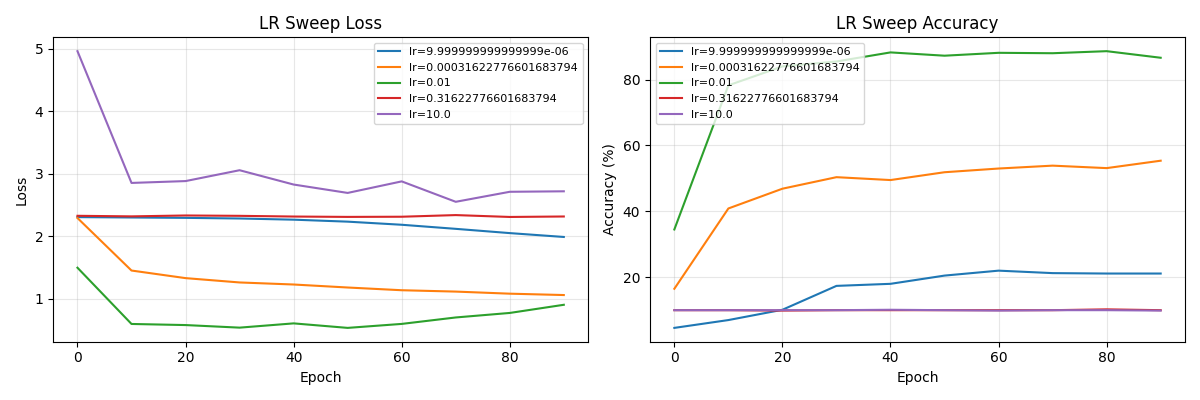

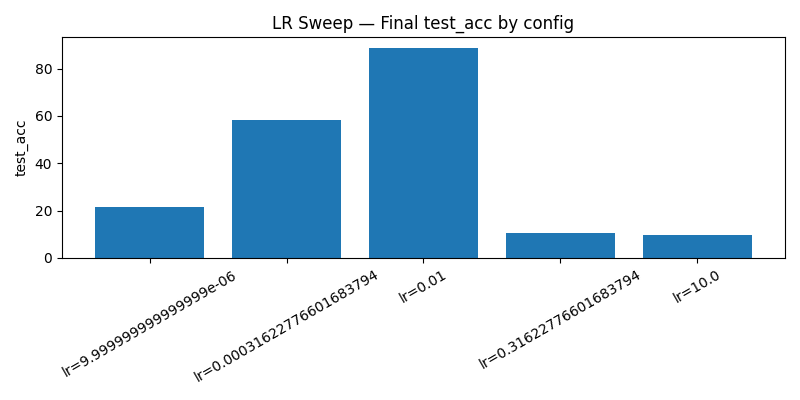


--- [batch_size] Config: batch_size=16 ---
epoch 0, dt 0.57s, train_loss 1.834e+00, val_loss 1.384e+00, train_acc 43.0, val_acc 40.6
epoch 10, dt 6.16s, train_loss 6.666e-01, val_loss 6.221e-01, train_acc 85.7, val_acc 81.6
epoch 20, dt 5.41s, train_loss 2.573e-01, val_loss 6.348e-01, train_acc 89.7, val_acc 83.1
epoch 30, dt 5.91s, train_loss 1.628e-02, val_loss 4.910e-01, train_acc 94.4, val_acc 86.4
epoch 40, dt 6.37s, train_loss 1.635e-01, val_loss 5.607e-01, train_acc 94.6, val_acc 88.9
epoch 50, dt 6.25s, train_loss 2.963e-01, val_loss 5.270e-01, train_acc 93.7, val_acc 85.6
epoch 60, dt 5.72s, train_loss 8.754e-02, val_loss 6.250e-01, train_acc 92.5, val_acc 85.2
epoch 70, dt 5.92s, train_loss 7.667e-03, val_loss 5.509e-01, train_acc 94.2, val_acc 87.4
epoch 80, dt 6.38s, train_loss 2.580e-02, val_loss 5.654e-01, train_acc 96.3, val_acc 87.5
epoch 90, dt 6.73s, train_loss 1.681e-05, val_loss 5.899e-01, train_acc 98.0, val_acc 88.9
Final result: train_loss 1.388e-01, val_loss 5.

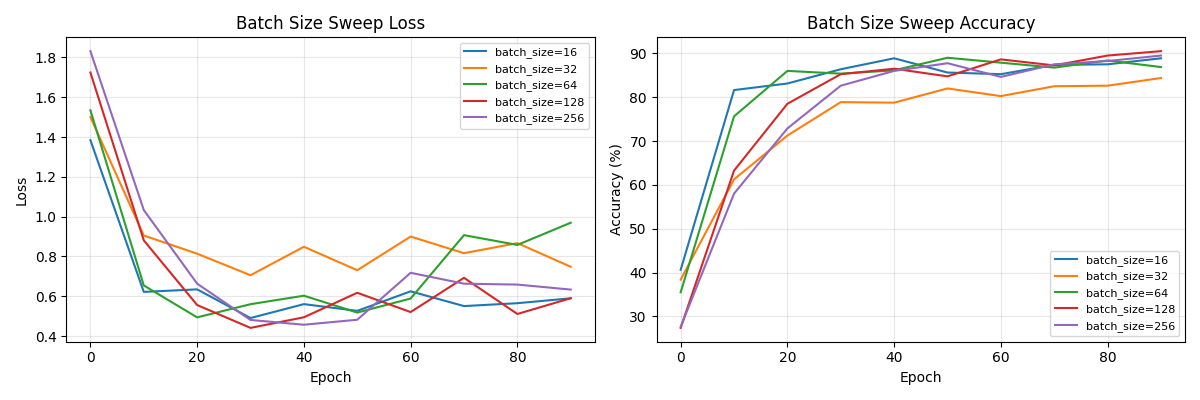

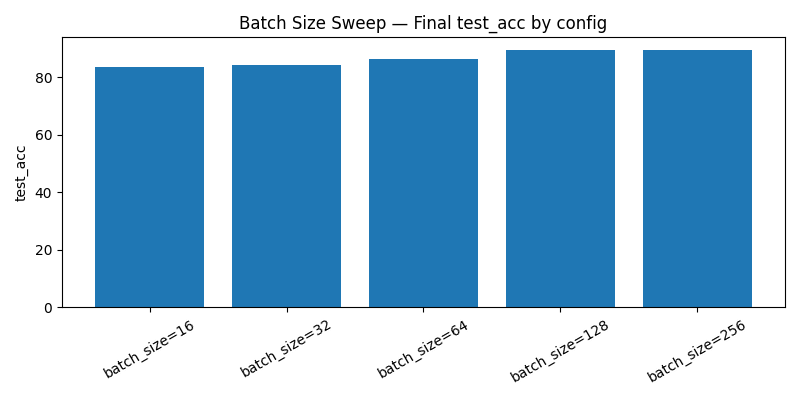


--- [epochs] Config: epochs=10 ---
epoch 0, dt 0.21s, train_loss 1.672e+00, val_loss 1.642e+00, train_acc 36.2, val_acc 36.4
Final result: train_loss 5.933e-01, val_loss 1.642e+00, test_loss 6.340e-01, train_acc 36.2, val_acc 36.4, test_acc 73.8

--- [epochs] Config: epochs=50 ---
epoch 0, dt 0.19s, train_loss 1.440e+00, val_loss 1.484e+00, train_acc 41.5, val_acc 37.8
epoch 10, dt 1.66s, train_loss 7.613e-01, val_loss 8.816e-01, train_acc 69.1, val_acc 63.6
epoch 20, dt 1.50s, train_loss 4.010e-01, val_loss 7.174e-01, train_acc 87.8, val_acc 76.6
epoch 30, dt 1.51s, train_loss 1.643e-01, val_loss 4.997e-01, train_acc 95.7, val_acc 86.9
epoch 40, dt 1.55s, train_loss 1.461e-01, val_loss 6.993e-01, train_acc 95.8, val_acc 86.4
Final result: train_loss 1.873e-02, val_loss 6.993e-01, test_loss 4.952e-01, train_acc 95.8, val_acc 86.4, test_acc 88.4

--- [epochs] Config: epochs=100 ---
epoch 0, dt 0.14s, train_loss 1.503e+00, val_loss 1.484e+00, train_acc 40.5, val_acc 40.1
epoch 10, dt 1.

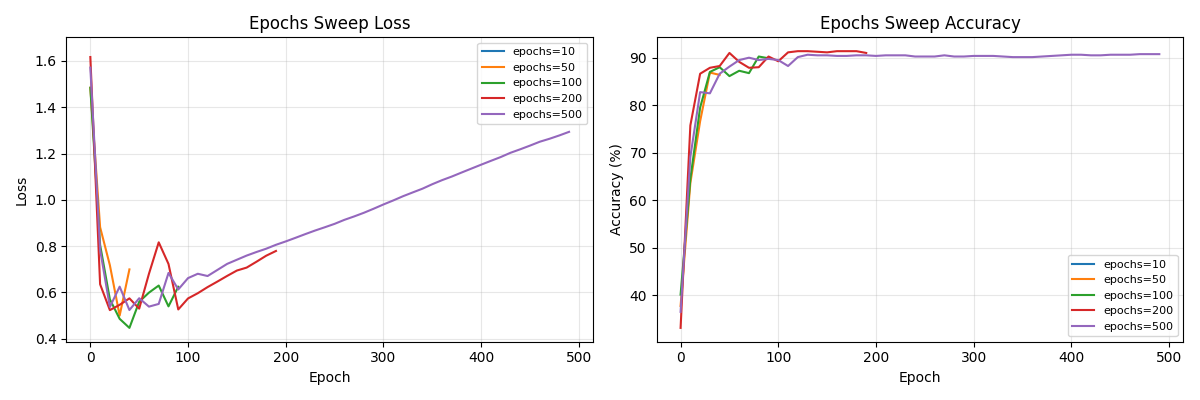

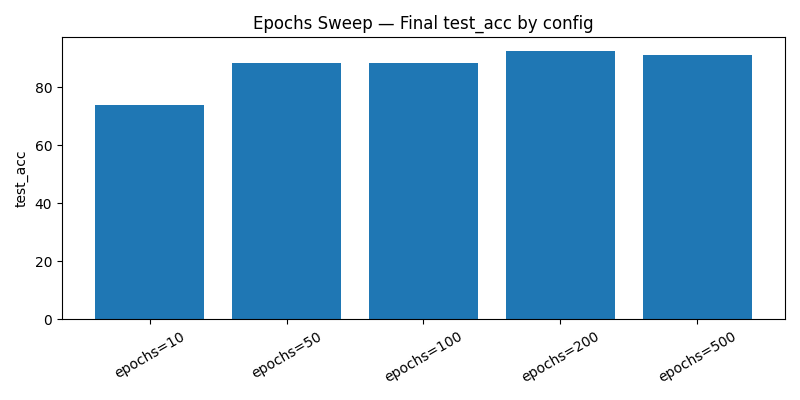

In [3]:
sweep_results = {}

# --- Learning rate sweep ---
lrs = np.logspace(-5, 1, 5)
configs = [{"lr": float(lr)} for lr in lrs]
sweep_results["lr"] = run_sweep(data, lambda: SimpleCNN(), configs, sweep_name="lr")
plot_sweep(sweep_results["lr"], metric="val_acc", title_prefix="LR Sweep")
plot_final_comparison(sweep_results["lr"], metric="test_acc", title_prefix="LR Sweep")

# --- Batch size sweep ---
batch_sizes = [2**i for i in range(4, 9)]
configs = [{"batch_size": int(bs)} for bs in batch_sizes]
sweep_results["batch_size"] = run_sweep(data, lambda: SimpleCNN(), configs, sweep_name="batch_size")
plot_sweep(sweep_results["batch_size"], metric="val_acc", title_prefix="Batch Size Sweep")
plot_final_comparison(sweep_results["batch_size"], metric="test_acc", title_prefix="Batch Size Sweep")

# --- Epochs sweep ---
epoch_list = [10, 50, 100, 200, 500]
configs = [{"epochs": int(e)} for e in epoch_list]
sweep_results["epochs"] = run_sweep(data, lambda: SimpleCNN(), configs, sweep_name="epochs")
plot_sweep(sweep_results["epochs"], metric="val_acc", title_prefix="Epochs Sweep")
plot_final_comparison(sweep_results["epochs"], metric="test_acc", title_prefix="Epochs Sweep")


--- [kernel_size] Config: kernel_size=1, linear_in=25 ---
epoch 0, dt 0.52s, train_loss 2.260e+00, val_loss 2.183e+00, train_acc 15.2, val_acc 15.6
epoch 10, dt 2.16s, train_loss 2.216e+00, val_loss 2.164e+00, train_acc 16.2, val_acc 17.4
epoch 20, dt 2.03s, train_loss 2.145e+00, val_loss 2.163e+00, train_acc 17.1, val_acc 16.4
epoch 30, dt 2.43s, train_loss 2.200e+00, val_loss 2.156e+00, train_acc 17.2, val_acc 18.0
epoch 40, dt 2.32s, train_loss 2.202e+00, val_loss 2.167e+00, train_acc 17.1, val_acc 16.8
epoch 50, dt 2.50s, train_loss 2.096e+00, val_loss 2.162e+00, train_acc 17.7, val_acc 17.1
epoch 60, dt 2.53s, train_loss 2.150e+00, val_loss 2.162e+00, train_acc 18.2, val_acc 16.5
epoch 70, dt 2.45s, train_loss 2.135e+00, val_loss 2.163e+00, train_acc 17.7, val_acc 16.2
epoch 80, dt 1.98s, train_loss 2.156e+00, val_loss 2.182e+00, train_acc 16.9, val_acc 17.1
epoch 90, dt 1.68s, train_loss 2.161e+00, val_loss 2.168e+00, train_acc 17.3, val_acc 17.2
Final result: train_loss 2.209e+

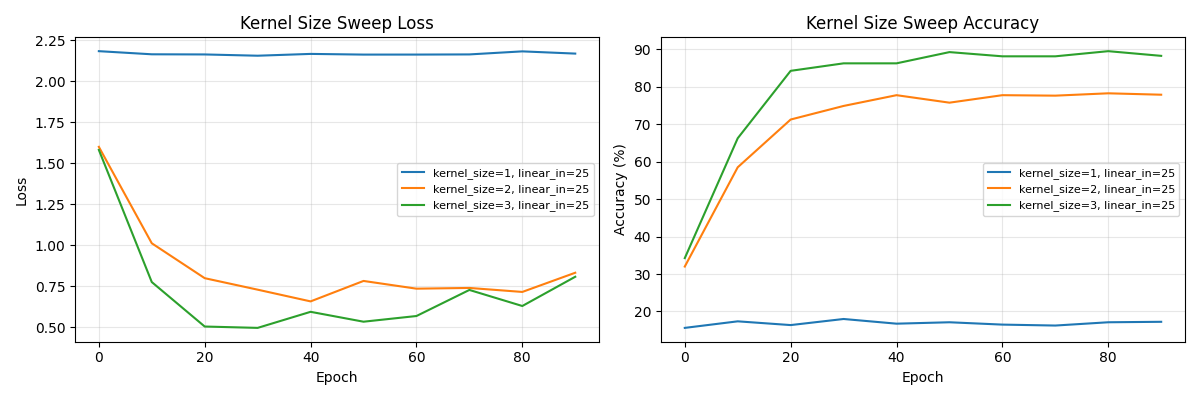

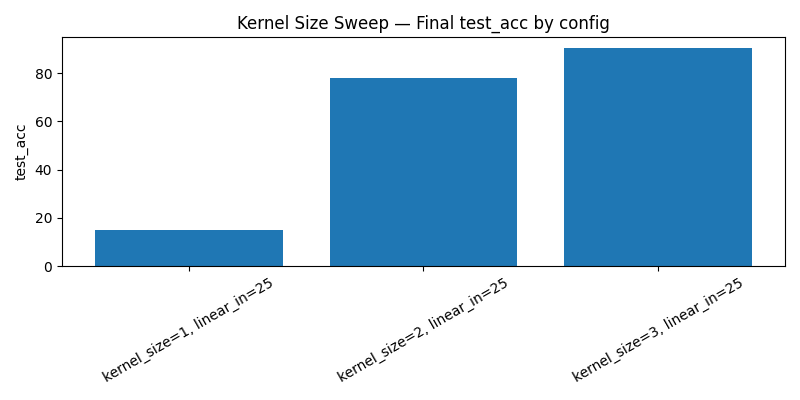


--- [channels] Config: channels=5, linear_in=5 ---
epoch 0, dt 0.17s, train_loss 2.073e+00, val_loss 2.047e+00, train_acc 22.6, val_acc 21.9
epoch 10, dt 1.63s, train_loss 1.117e+00, val_loss 1.279e+00, train_acc 49.6, val_acc 46.5
epoch 20, dt 1.63s, train_loss 1.064e+00, val_loss 1.235e+00, train_acc 52.6, val_acc 48.9
epoch 30, dt 1.64s, train_loss 1.097e+00, val_loss 1.170e+00, train_acc 54.1, val_acc 52.9
epoch 40, dt 1.70s, train_loss 1.060e+00, val_loss 1.208e+00, train_acc 54.3, val_acc 50.8
epoch 50, dt 1.88s, train_loss 9.528e-01, val_loss 1.144e+00, train_acc 55.9, val_acc 53.4
epoch 60, dt 1.49s, train_loss 1.340e+00, val_loss 1.117e+00, train_acc 58.2, val_acc 54.5
epoch 70, dt 1.46s, train_loss 1.196e+00, val_loss 1.106e+00, train_acc 59.5, val_acc 55.8
epoch 80, dt 1.60s, train_loss 9.677e-01, val_loss 1.090e+00, train_acc 61.3, val_acc 56.8
epoch 90, dt 1.51s, train_loss 9.100e-01, val_loss 1.021e+00, train_acc 64.1, val_acc 57.8
Final result: train_loss 7.515e-01, val

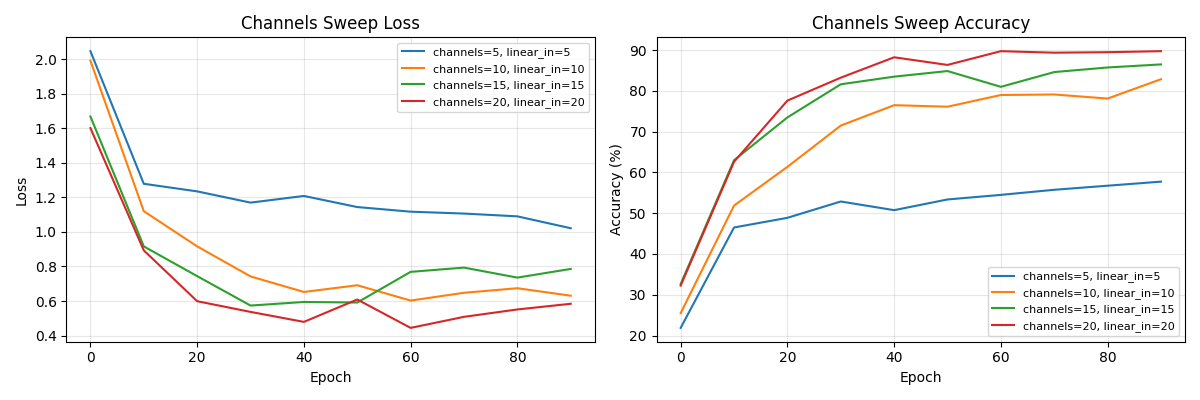

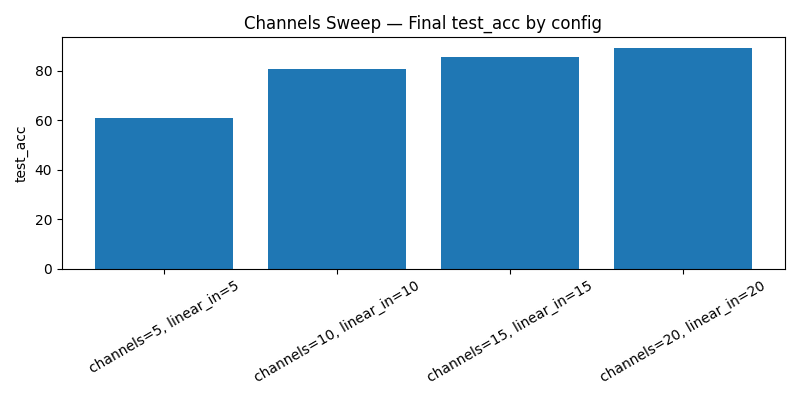


--- [stride] Config: stride=1, linear_in=250 ---
epoch 0, dt 0.37s, train_loss 1.344e+00, val_loss 1.331e+00, train_acc 44.0, val_acc 42.6
epoch 10, dt 2.65s, train_loss 3.460e-02, val_loss 1.967e-01, train_acc 98.7, val_acc 94.8
epoch 20, dt 2.32s, train_loss 7.154e-04, val_loss 2.162e-01, train_acc 99.3, val_acc 96.0
epoch 30, dt 2.36s, train_loss 1.081e-01, val_loss 4.148e-01, train_acc 94.8, val_acc 89.8
epoch 40, dt 2.16s, train_loss 4.139e-05, val_loss 2.193e-01, train_acc 100.0, val_acc 96.8
epoch 50, dt 2.13s, train_loss 1.638e-05, val_loss 2.207e-01, train_acc 100.0, val_acc 97.0
epoch 60, dt 2.39s, train_loss 6.436e-05, val_loss 2.243e-01, train_acc 100.0, val_acc 97.0
epoch 70, dt 2.96s, train_loss 9.357e-06, val_loss 2.283e-01, train_acc 100.0, val_acc 97.0
epoch 80, dt 2.53s, train_loss 2.107e-05, val_loss 2.323e-01, train_acc 100.0, val_acc 97.0
epoch 90, dt 2.41s, train_loss 2.306e-06, val_loss 2.360e-01, train_acc 100.0, val_acc 97.0
Final result: train_loss 1.098e-05,

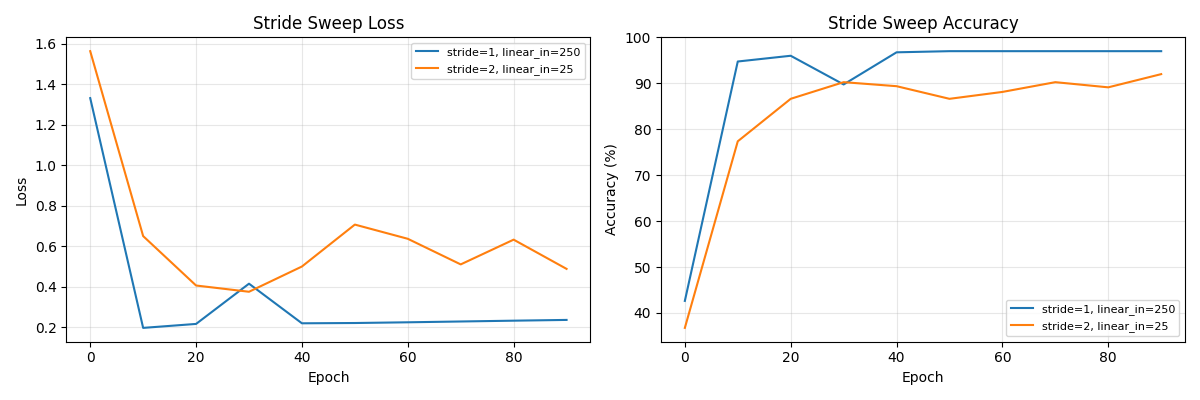

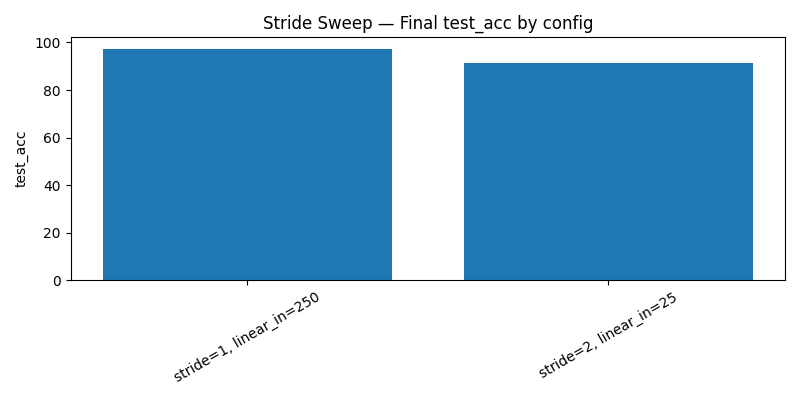

In [4]:
def run_sweep_class_hyperparameter(data, model_fn, configs: list[dict], sweep_name: str = "") -> dict[str, dict]:
    all_results = {}
    for cfg in configs:
        label = ", ".join(f"{k}={v}" for k, v in cfg.items())
        print(f"\n--- [{sweep_name}] Config: {label} ---")
        model = model_fn(**cfg)          # pass config to constructor
        results = train_model(data, model)  # no **cfg here
        results["num_params"] = count_model_params(model)
        all_results[label] = results
    return all_results

def compute_linear_in(input_size=40, channels=25, kernel_size=3, stride=2, padding=1):
    size = input_size
    # block 1: 2 convs + pool
    for _ in range(2):
        size = (size + 2*padding - kernel_size) // stride + 1
    size = size // 2
    # block 2: 2 convs + pool
    for _ in range(2):
        size = (size + 2*padding - kernel_size) // stride + 1
    size = size // 2
    return size * channels

#--- Kernel Size sweep ---
kernel_sizes = [1, 2, 3]
configs = [{"kernel_size": int(k), "linear_in": compute_linear_in(kernel_size=int(k))} for k in kernel_sizes]
sweep_results["kernel_size"] = run_sweep_class_hyperparameter(data, SimpleCNN, configs, sweep_name="kernel_size")
plot_sweep(sweep_results["kernel_size"], metric="val_acc", title_prefix="Kernel Size Sweep")
plot_final_comparison(sweep_results["kernel_size"], metric="test_acc", title_prefix="Kernel Size Sweep")

# -- No. Channels sweep ---
channel_list = [i for i in range(5, 25, 5)]
configs = [{"channels": int(c), "linear_in": int(c)} for c in channel_list]
sweep_results["channels"]    = run_sweep_class_hyperparameter(data, SimpleCNN, configs, sweep_name="channels")
plot_sweep(sweep_results["channels"], metric="val_acc", title_prefix="Channels Sweep")
plot_final_comparison(sweep_results["channels"], metric="test_acc", title_prefix="Channels Sweep")

# -- Stride sweep ---
strides = [1, 2]
configs = [{"stride": int(s), "linear_in": compute_linear_in(stride=int(s))} for s in strides]
sweep_results["stride"] = run_sweep_class_hyperparameter(data, SimpleCNN, configs, sweep_name="stride")
plot_sweep(sweep_results["stride"], metric="val_acc", title_prefix="Stride Sweep")
plot_final_comparison(sweep_results["stride"], metric="test_acc", title_prefix="Stride Sweep")

## Summary Table

In [5]:
summary_df = build_summary_table(sweep_results)
summary_df

,sweep,config,test_acc,val_acc_final,train_acc_final,val_loss_final,train_loss_final,num_params
0,batch_size,batch_size=128,89.5,90.500,100.00000,0.590306,5.078583e-04,6060
1,batch_size,batch_size=256,89.4,89.500,100.00000,0.633788,1.375056e-03,6060
2,batch_size,batch_size=64,86.5,86.875,97.03125,0.969574,1.913787e-02,6060
3,batch_size,batch_size=32,84.5,84.375,95.71875,0.748352,5.148472e-01,6060
4,batch_size,batch_size=16,83.6,88.875,97.96875,0.589902,1.388200e-01,6060
5,channels,"channels=20, linear_in=20",89.0,89.750,100.00000,0.583869,2.014041e-04,3950
6,channels,"channels=15, linear_in=15",85.4,86.500,96.81250,0.785753,1.439218e-01,2290
7,channels,"channels=10, linear_in=10",80.7,82.875,88.90625,0.630663,2.037381e-01,1080
8,channels,"channels=5, linear_in=5",60.8,57.750,64.09375,1.021388,7.515295e-01,320
9,epochs,epochs=200,92.5,91.000,100.00000,0.778976,1.270722e-05,6060
